In [ ]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

sys.path.append("../../")
from xThreat import xThreat

In [ ]:
data_path = '../../1-data-preparation/data-storage/xThreat_data_v4.parquet'
df_events = pd.read_parquet(data_path, engine='fastparquet')
df_events['shot'] = ~df_events['shot_outcome'].isna()
df_events['goal'] = df_events['shot_outcome'] == 'Goal'
df_events.drop(columns=['id', 'shot_outcome', 'possession'], inplace=True)
df_size_bytes = df_events.memory_usage(deep=True).sum()
df_size_mb = df_size_bytes / (1024 ** 2)  # Convert to MB

print(f"DataFrame size: {df_size_mb:.2f} MB")

DataFrame size: 1287.32 MB


In [3]:
xT_model = xThreat(n_x=16, n_y=12)
xT_model.fit(df_events)

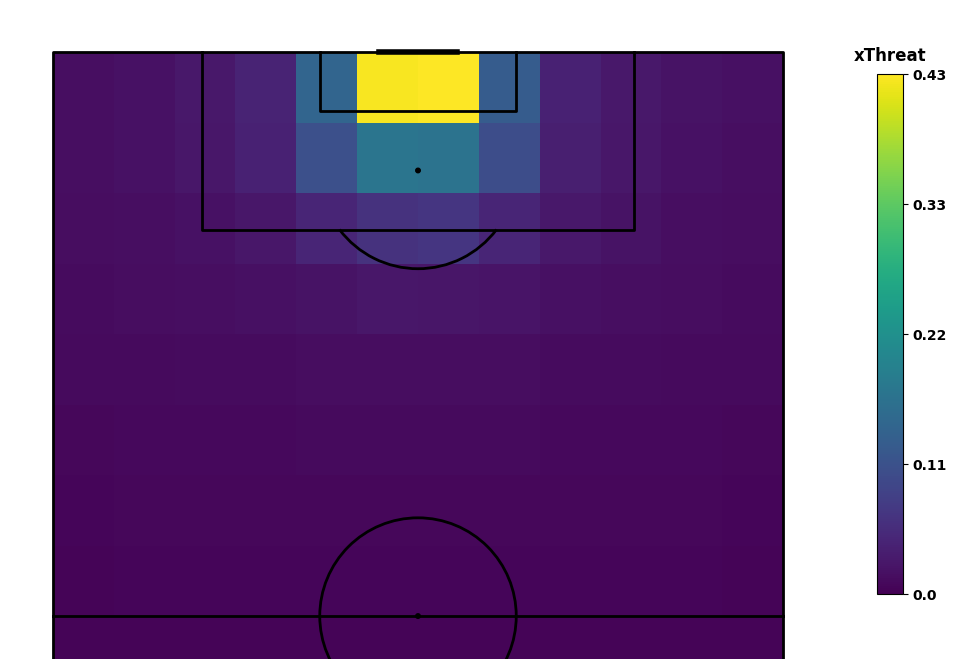

In [4]:
xT_model.plot_xThreat(cmap='viridis', half=True)

(<Figure size 1050x680 with 2 Axes>,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x1e828ae74a0>)

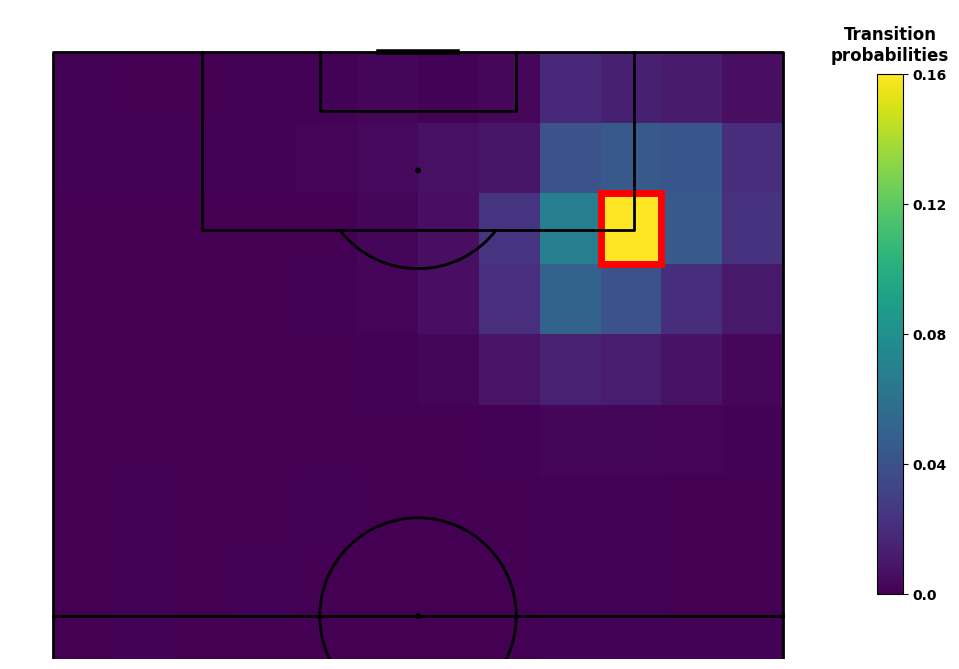

In [9]:
xT_model.plot_transitions_outgoing(
    x_i=13, y_i=2,
    cmap='viridis',
    half=True,
    edgecolor='red',
    linewidth=5,
)

(<Figure size 1050x680 with 2 Axes>,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x1b91b51f740>)

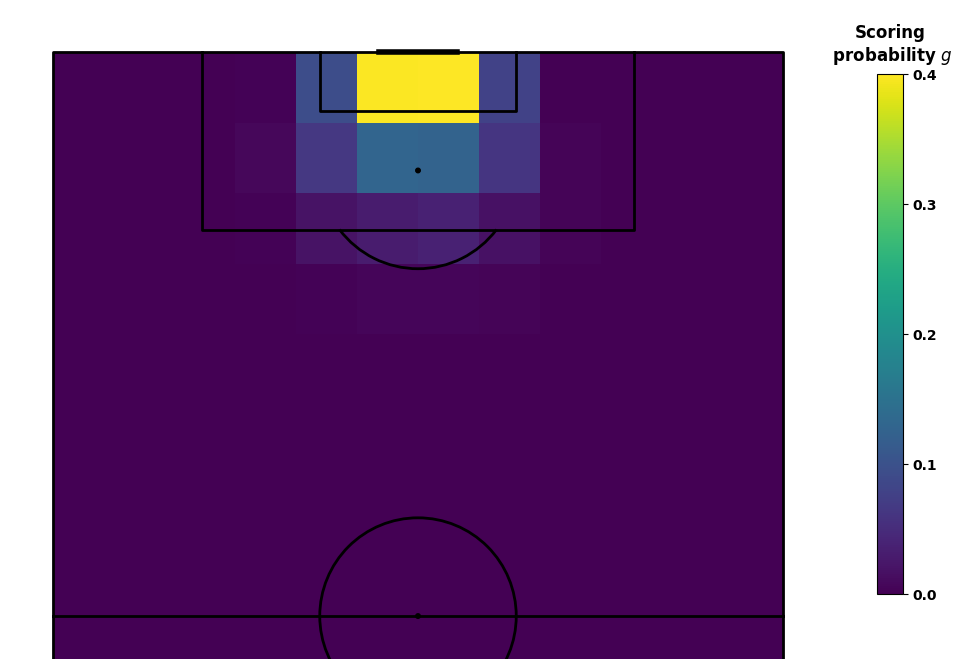

In [6]:
xT_model.plot_pitch_heatmap(
    values=xT_model.probability_shooting*xT_model.xG,
    cmap='viridis',
    colorbar_label='Scoring\n probability $g$',
    half=True,
)

In [7]:
iterations = [0, 1, 2, 3, 4, 9, 14, 19, 24, 29]
xT_dict = {}
xT_values_dict = {}
max_val = 0

for i in iterations:
    xT_temp = xT_model.copy()
    if i > 0:
        xT_temp._calculate_xThreat(max_iterations=i)
        xT_val = xT_temp.xT
    if i == 0:
        xT_val = xT_temp.probability_shooting*xT_temp.xG

    xT_dict[i] = xT_temp
    max_val = max(max_val, np.max(xT_val))
    xT_values_dict[i] = xT_val




Did not converge to a solution within the maximum number of iterations.
Did not converge to a solution within the maximum number of iterations.
Did not converge to a solution within the maximum number of iterations.
Did not converge to a solution within the maximum number of iterations.
Did not converge to a solution within the maximum number of iterations.
Did not converge to a solution within the maximum number of iterations.
Did not converge to a solution within the maximum number of iterations.
Did not converge to a solution within the maximum number of iterations.
Did not converge to a solution within the maximum number of iterations.


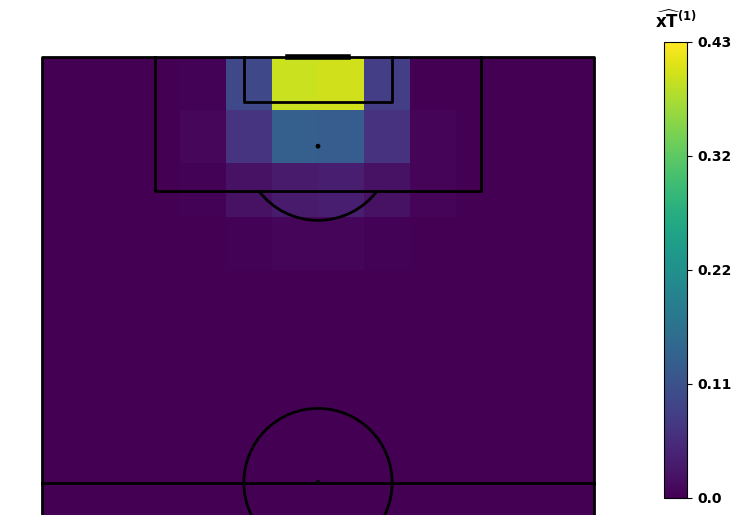

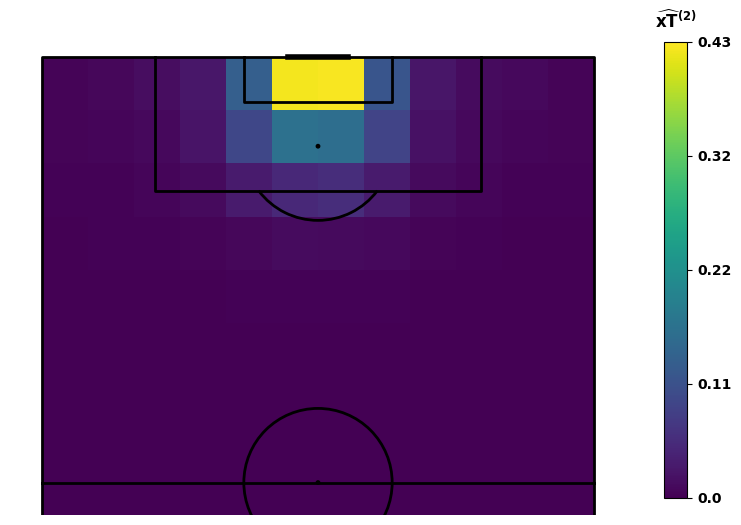

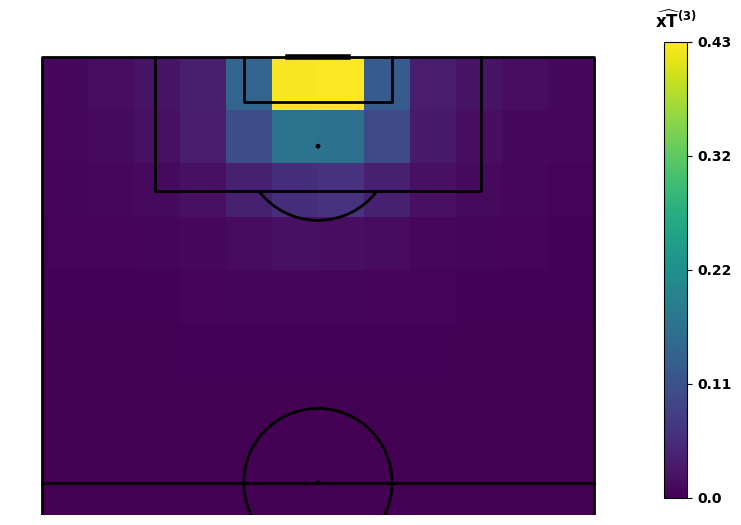

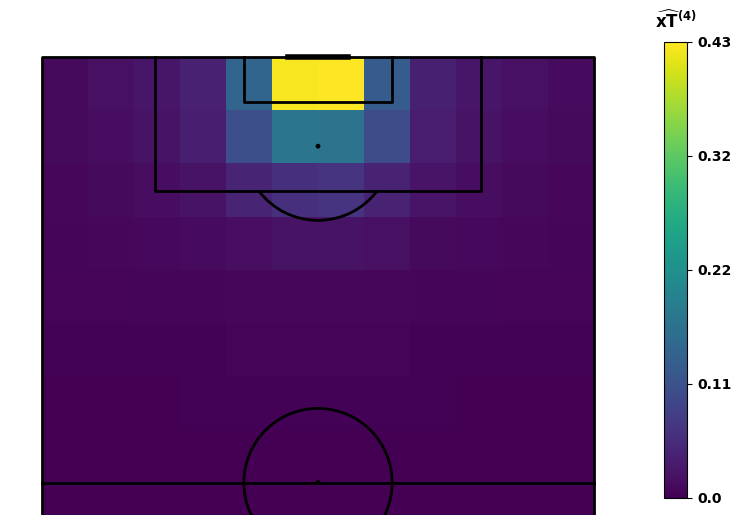

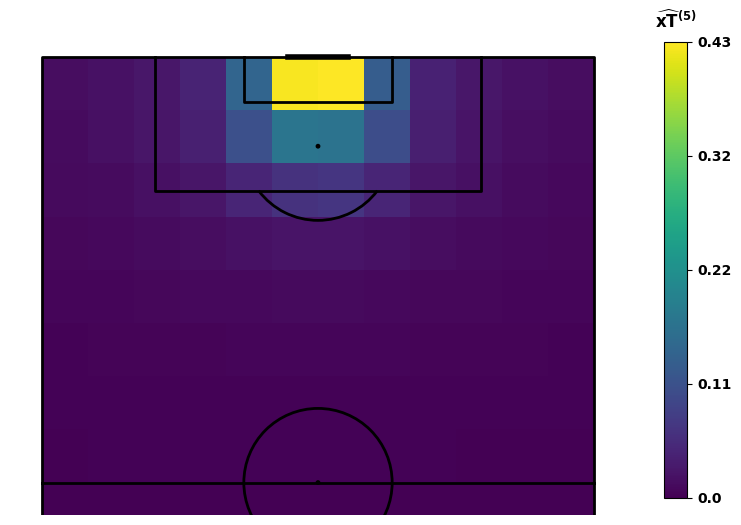

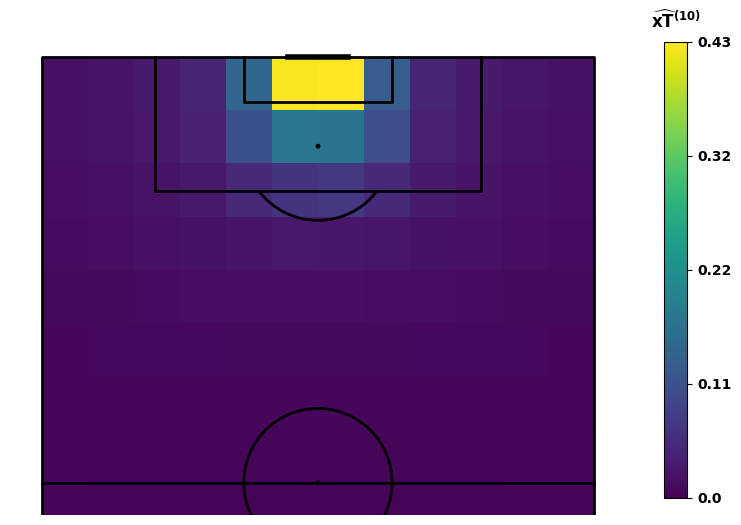

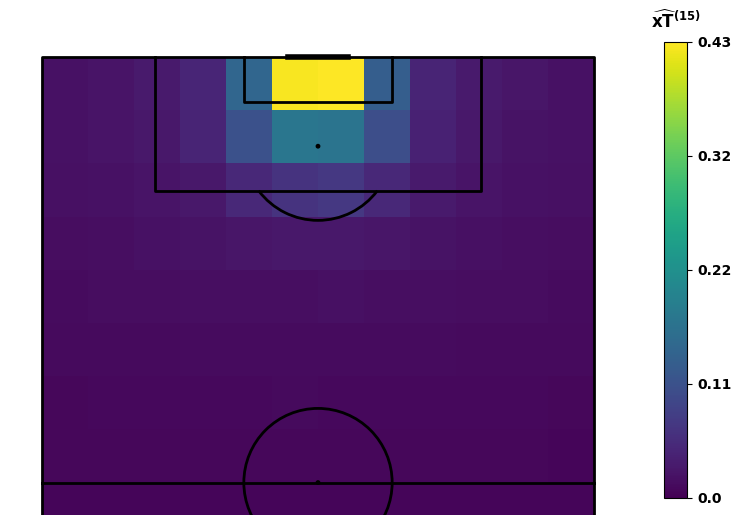

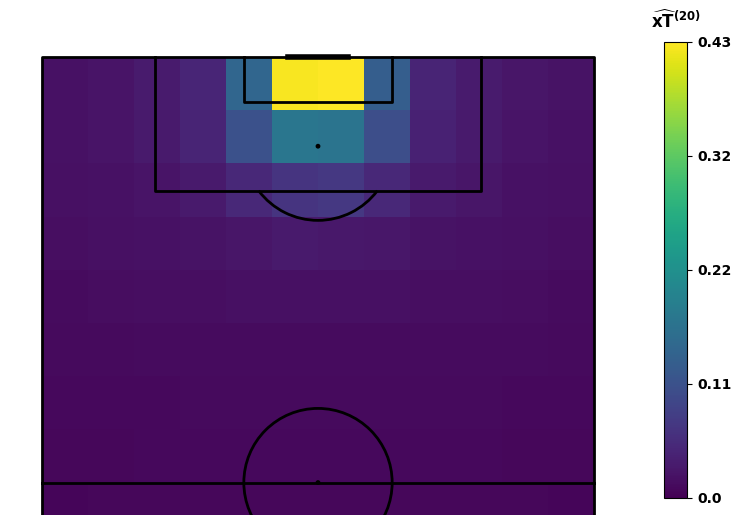

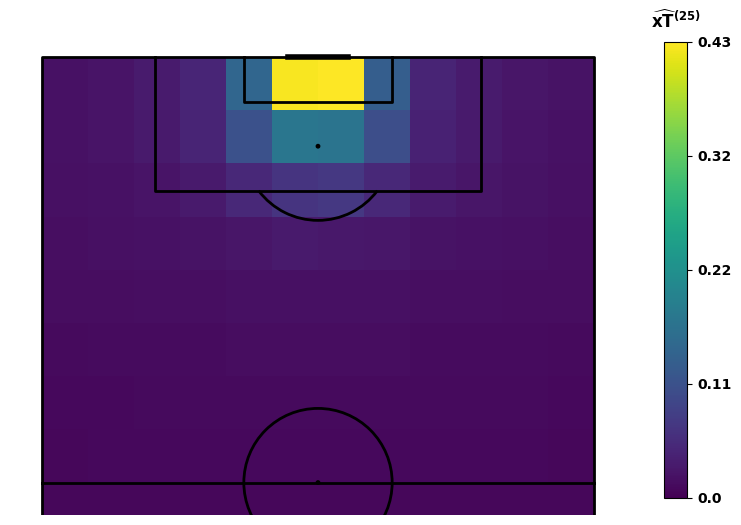

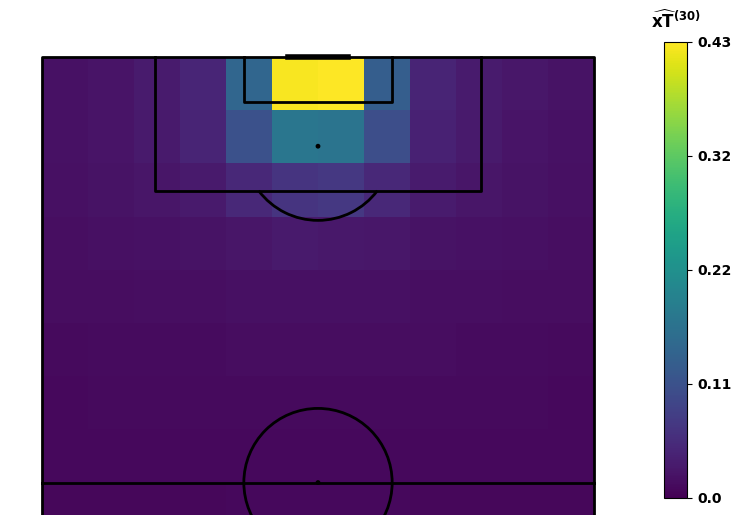

In [8]:
for i in iterations:
    xT_temp = xT_dict[i]
    local_max_val = xT_values_dict[i].max()
    fig, ax, cbar = xT_temp.plot_pitch_heatmap(
        xT_values_dict[i],
        cmap='viridis', figsize=(8, 6), 
        colorbar_label=f'$\\mathbf{{\\widehat{{xT}}^{{({i+1})}}}}$',
        half=True,
        )
    
    # Get the heatmap object and update limits
    heatmap = ax.collections[0]
    heatmap.set_clim(vmin=0, vmax=max_val)

    # Update colorbar ticks to match
    cbar.set_ticks(
        np.linspace(0, max_val, 5),
        labels=np.round(np.linspace(0, max_val, 5), decimals=2)
    )

    # # Add horizontal line on colorbar
    # cbar.ax.axhline(y=local_max_val, color='red', linewidth=1.5)

    # # Add annotation
    # cbar.ax.annotate(f'{local_max_val:.2f}', 
    #                 xy=(0, local_max_val), 
    #                 xytext=(-0.5, local_max_val),
    #                 color='red', fontsize=9, va='center', ha='right', fontweight='bold')

    plt.show()

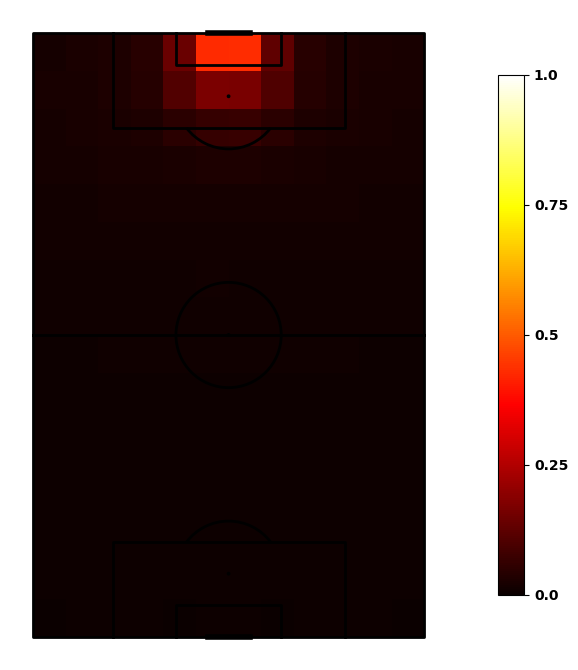

In [9]:
import numpy as np

fig, ax, cbar = xT_temp.plot_pitch_heatmap(xT_temp.xT)

# Get the heatmap object and update limits
heatmap = ax.collections[0]
heatmap.set_clim(vmin=0, vmax=1)

# Update colorbar ticks to match
cbar.set_ticks(
    np.linspace(0, 1, 5),
    labels=np.round(np.linspace(0, 1, 5), decimals=2)
)